# Predictive Maintenance — K-Means Clustering
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Goal:** Cluster machine operating conditions into health states: Optimal, Degrading, Critical Failure Risk  
**Stack:** scikit-learn · joblib · boto3 (floci S3 endpoint)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import boto3
import os

print('All imports OK')

All imports OK


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('../Dataset/ai4i2020.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
# Check nulls
print('Null counts:')
print(df.isnull().sum())

Null counts:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


## 3. EDA — Feature Distributions

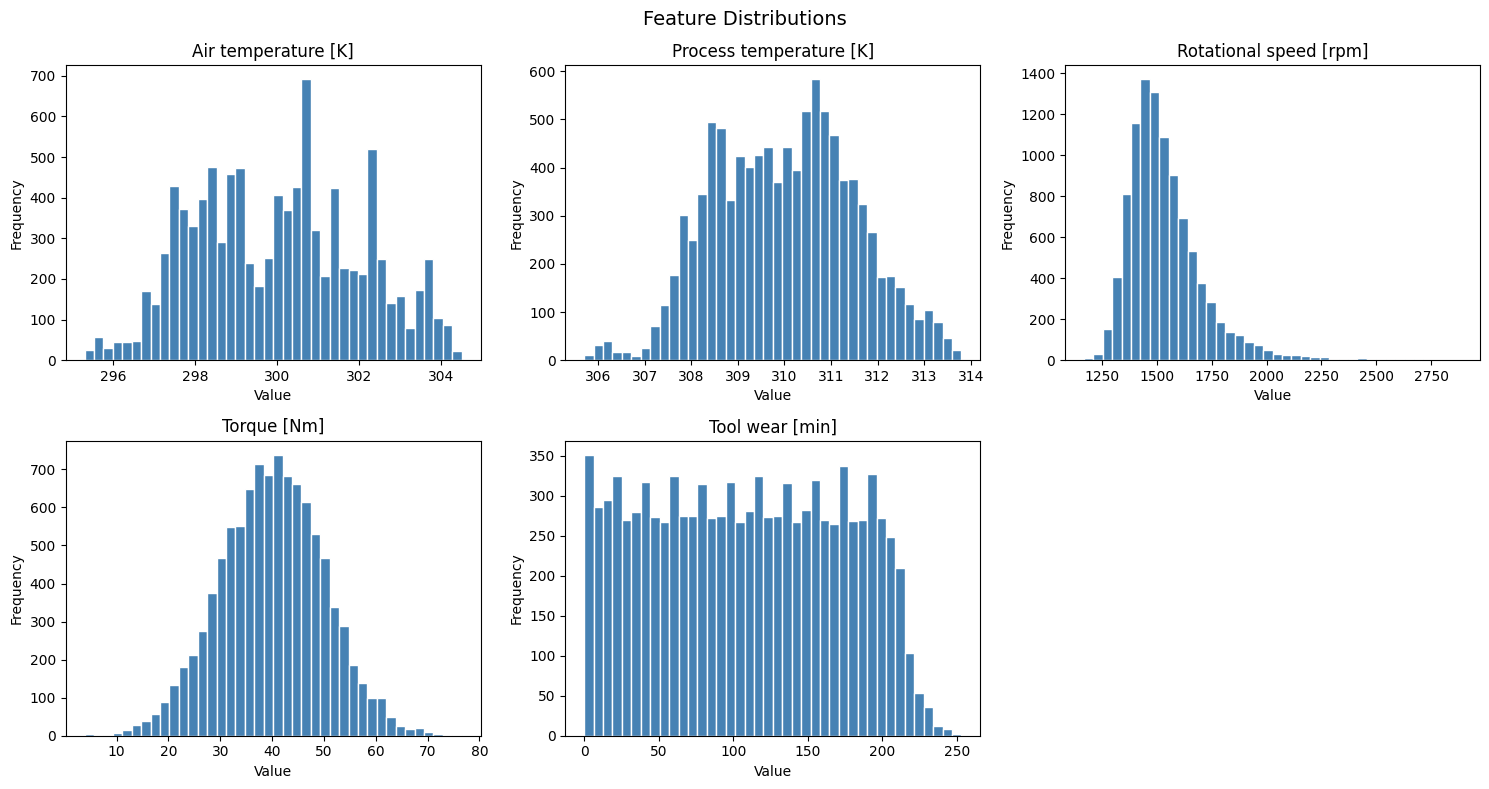

In [6]:
FEATURES = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../model/feature_distributions.png', dpi=100)
plt.show()

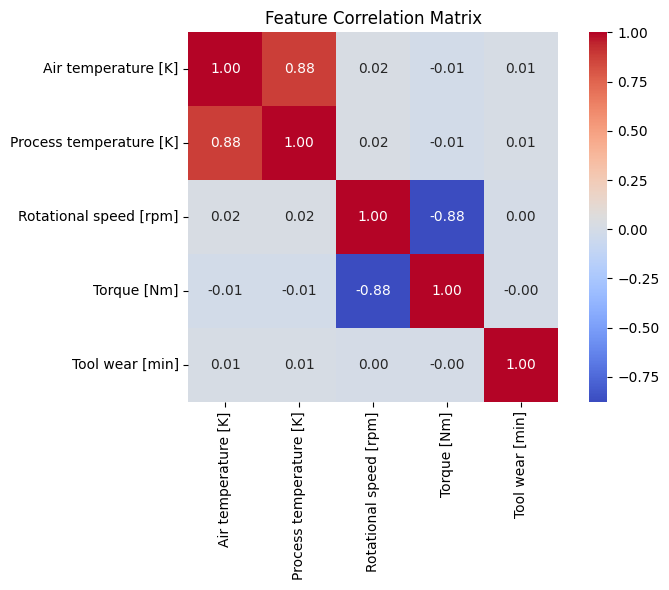

In [7]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../model/correlation_heatmap.png', dpi=100)
plt.show()

## 4. Preprocessing — StandardScaler

In [8]:
X = df[FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Scaled shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(4)}')

Scaled shape: (10000, 5)
Mean (should be ~0): [-0.  0. -0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


## 5. Find Optimal K — Elbow Method + Silhouette Score

In [9]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}')

k=2  inertia=36654.2  silhouette=0.2581
k=3  inertia=28305.7  silhouette=0.2622
k=4  inertia=24870.6  silhouette=0.2376
k=5  inertia=21946.7  silhouette=0.2250
k=6  inertia=19849.0  silhouette=0.2200
k=7  inertia=17896.0  silhouette=0.2256
k=8  inertia=16591.0  silhouette=0.2176


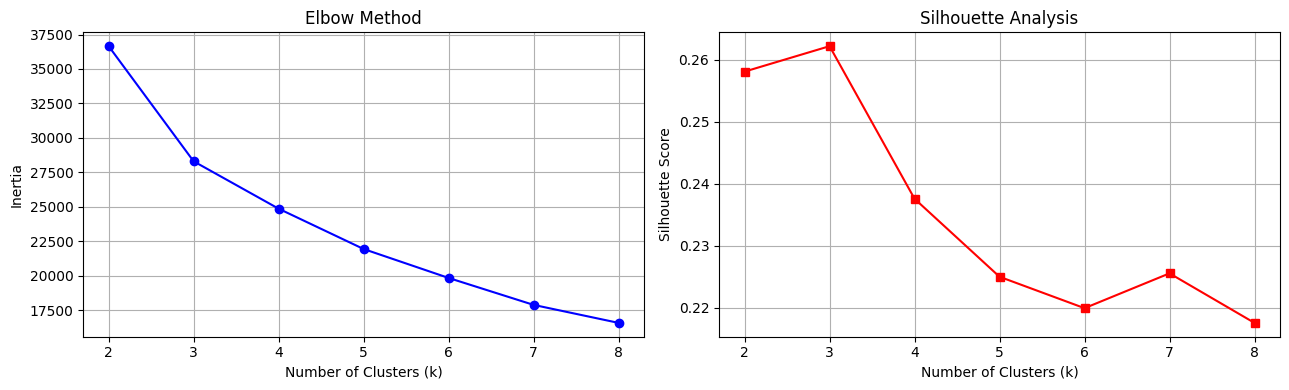

Best k by silhouette: 3


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(list(K_range), silhouettes, 'rs-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../model/elbow_silhouette.png', dpi=100)
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'Best k by silhouette: {best_k}')

## 6. Train Final Model (k=3)

In [11]:
# k=3 maps cleanly to: Optimal | Degrading | Critical Failure Risk
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Cluster counts:')
print(df['cluster'].value_counts().sort_index())
print(f'\nFinal inertia: {kmeans.inertia_:.2f}')
print(f'Silhouette score: {silhouette_score(X_scaled, df["cluster"]):.4f}')

Cluster counts:
cluster
0    3930
1    4017
2    2053
Name: count, dtype: int64

Final inertia: 28305.69
Silhouette score: 0.2622


In [12]:
# Profile each cluster — understand what each represents
cluster_profile = df.groupby('cluster')[FEATURES].mean()
print('Cluster Centroids (original scale):')
cluster_profile

Cluster Centroids (original scale):


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
cluster,,,,,
0,301.723308,311.246590,1469.807379,43.643333,110.358270
1,298.264252,308.741524,1474.144884,43.264600,104.624844
2,300.121383,310.103166,1797.261568,26.574233,109.850950


In [13]:
# Map cluster IDs to human-readable health states
# Sort by Tool wear [min] ascending → Optimal=low wear, Critical=high wear
wear_order = cluster_profile['Tool wear [min]'].sort_values().index.tolist()
STATE_MAP = {
    wear_order[0]: 'Optimal',
    wear_order[1]: 'Degrading',
    wear_order[2]: 'Critical Failure Risk'
}
print('Cluster → State mapping:')
for cluster_id, state in STATE_MAP.items():
    print(f'  Cluster {cluster_id} → {state}')

df['health_state'] = df['cluster'].map(STATE_MAP)

Cluster → State mapping:
  Cluster 1 → Optimal
  Cluster 2 → Degrading
  Cluster 0 → Critical Failure Risk


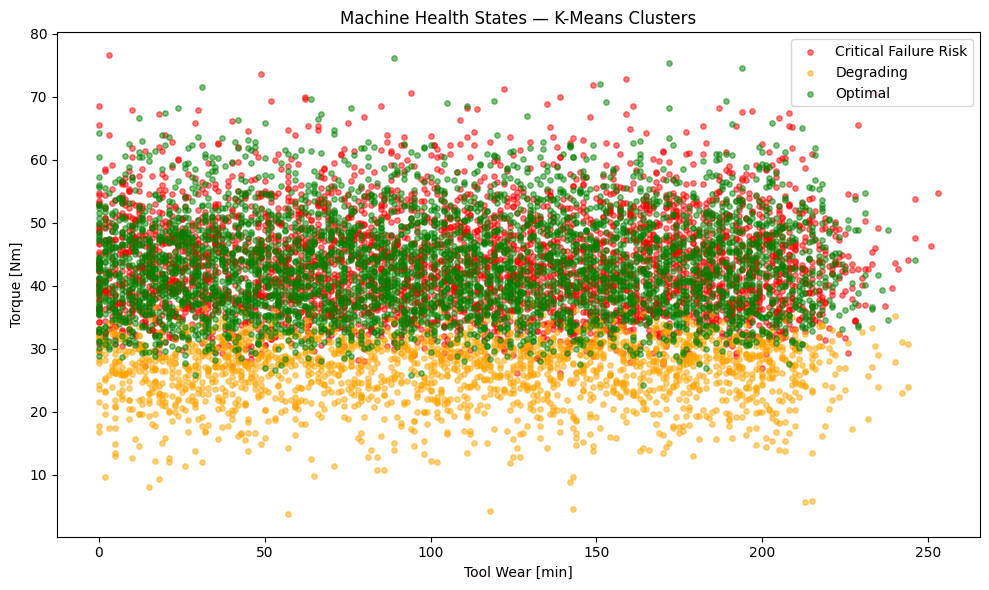

In [14]:
# Visualize clusters (Torque vs Tool wear — most informative pair)
colors = {'Optimal': 'green', 'Degrading': 'orange', 'Critical Failure Risk': 'red'}

plt.figure(figsize=(10, 6))
for state, grp in df.groupby('health_state'):
    plt.scatter(grp['Tool wear [min]'], grp['Torque [Nm]'],
                c=colors[state], label=state, alpha=0.5, s=15)

plt.xlabel('Tool Wear [min]')
plt.ylabel('Torque [Nm]')
plt.title('Machine Health States — K-Means Clusters')
plt.legend()
plt.tight_layout()
plt.savefig('../model/cluster_visualization.png', dpi=100)
plt.show()

## 7. Save Model Artifacts

In [15]:
MODEL_DIR = '../model'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save KMeans model
joblib.dump(kmeans, f'{MODEL_DIR}/kmeans_model.pkl')
print('Saved: kmeans_model.pkl')

# Save scaler (MUST ship with model — same scaler used at training time)
joblib.dump(scaler, f'{MODEL_DIR}/scaler.pkl')
print('Saved: scaler.pkl')

# Save state map for cluster ID → label resolution
import json
# Convert int keys to str for JSON
state_map_str = {str(k): v for k, v in STATE_MAP.items()}
with open(f'{MODEL_DIR}/state_map.json', 'w') as f:
    json.dump(state_map_str, f, indent=2)
print('Saved: state_map.json')

# Save feature list so API uses exact same columns in same order
with open(f'{MODEL_DIR}/features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)
print('Saved: features.json')

Saved: kmeans_model.pkl
Saved: scaler.pkl
Saved: state_map.json
Saved: features.json


In [16]:
# Quick sanity check — re-load and predict one row
loaded_model = joblib.load(f'{MODEL_DIR}/kmeans_model.pkl')
loaded_scaler = joblib.load(f'{MODEL_DIR}/scaler.pkl')

sample = X.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)[0]
print(f'Sample prediction → Cluster {pred} → {STATE_MAP[pred]}')

Sample prediction → Cluster 1 → Optimal


## 8. Upload Model Artifacts to S3 (via floci)

> **Pre-requisite:** `floci start` must be running and you must have run `eval $(floci env)` (Linux/Mac) or `floci env` in your shell before launching Jupyter.  
> On Windows run: `floci env` output → set those env vars manually, or set them in the cell below.

In [17]:
# --- Configure floci S3 endpoint ---
# If you ran `floci env` in your shell before starting Jupyter these are already set.
# Otherwise set them here:

FLOCI_ENDPOINT = os.environ.get('AWS_ENDPOINT_URL', 'http://localhost:4566')
AWS_ACCESS_KEY  = os.environ.get('AWS_ACCESS_KEY_ID', 'test')
AWS_SECRET_KEY  = os.environ.get('AWS_SECRET_ACCESS_KEY', 'test')
AWS_REGION      = os.environ.get('AWS_DEFAULT_REGION', 'us-east-1')

print(f'Using endpoint: {FLOCI_ENDPOINT}')

S3_BUCKET = 'predictive-maintenance'
S3_PREFIX = 'model'

s3 = boto3.client(
    's3',
    endpoint_url=FLOCI_ENDPOINT,
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=AWS_REGION
)

Using endpoint: http://localhost:4566


In [18]:
# Create bucket
try:
    s3.create_bucket(Bucket=S3_BUCKET)
    print(f'Bucket created: s3://{S3_BUCKET}')
except s3.exceptions.BucketAlreadyOwnedByYou:
    print(f'Bucket already exists: s3://{S3_BUCKET}')
except Exception as e:
    print(f'Bucket error: {e}')

Bucket created: s3://predictive-maintenance


In [19]:
# Upload all model artifacts
artifacts = [
    'kmeans_model.pkl',
    'scaler.pkl',
    'state_map.json',
    'features.json'
]

for artifact in artifacts:
    local_path = f'{MODEL_DIR}/{artifact}'
    s3_key = f'{S3_PREFIX}/{artifact}'
    s3.upload_file(local_path, S3_BUCKET, s3_key)
    print(f'Uploaded: {local_path} → s3://{S3_BUCKET}/{s3_key}')

Uploaded: ../model/kmeans_model.pkl → s3://predictive-maintenance/model/kmeans_model.pkl
Uploaded: ../model/scaler.pkl → s3://predictive-maintenance/model/scaler.pkl
Uploaded: ../model/state_map.json → s3://predictive-maintenance/model/state_map.json
Uploaded: ../model/features.json → s3://predictive-maintenance/model/features.json


In [20]:
# Verify upload — list bucket contents
response = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix=S3_PREFIX)
print(f'Objects in s3://{S3_BUCKET}/{S3_PREFIX}:')
for obj in response.get('Contents', []):
    print(f'  {obj["Key"]}  ({obj["Size"]} bytes)')

Objects in s3://predictive-maintenance/model:
  model/features.json  (128 bytes)
  model/kmeans_model.pkl  (40855 bytes)
  model/scaler.pkl  (1039 bytes)
  model/state_map.json  (76 bytes)


## Done
Model artifacts saved locally in `../model/` and uploaded to `s3://predictive-maintenance/model/`.  
Next step: deploy `../api/` as FastAPI on EC2 via floci (see `README.md`).